# MVP Backtest Inspection

This notebook is the inspection-first path for validating the new `src/` package code.

Goals:
- verify Alpaca config still works
- fetch historical bars
- run the same strategy and risk stack used by the CLI
- inspect step-level outputs before touching live orders


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

repo_root, src_path

(WindowsPath('C:/Users/Eddie/Programming/securities-analysis'),
 WindowsPath('C:/Users/Eddie/Programming/securities-analysis/src'))

In [2]:
import json
from dataclasses import asdict

import numpy as np
import pandas as pd

from securities_analysis.backtest.costs import ExecutionCostModel
from securities_analysis.backtest.engine import StrategyBacktester
from securities_analysis.backtest.reporting import save_backtest_artifacts
from securities_analysis.config import load_alpaca_settings
from securities_analysis.execution.alpaca import AlpacaTrader
from securities_analysis.risk.policy import RiskPolicy
from securities_analysis.strategies.trend_following import TimeSeriesMomentumStrategy

## Configure The Run

Start with one liquid symbol and a simple frequency. `SPY` daily bars is the easiest first test.

If Alpaca auth is stale, this is one of the first places it will show up.

In [3]:
cfg_path = repo_root / 'data' / 'alpaca_keys.cfg'

symbol = 'SPY'
asset_class = 'equity'
start = '2024-01-01'
end = '2024-12-31'
freq = 'day'

initial_equity = 100_000.0
spread_bps = 1.0
commission_bps = 0.0
slippage_bps = 2.0
market_impact_bps_per_turnover = 5.0

lookback_bars = 30
vol_lookback_bars = 20
target_volatility = 0.20
max_gross_leverage = 1.0
max_position_notional_pct = 0.20
max_trade_notional_pct = 0.10
max_daily_drawdown_pct = 0.03
max_spread_bps = 20.0
fractional_kelly = 0.25
max_kelly_fraction = 0.50
allow_short = False

periods_per_year_map = {
    'minute': int(252 * 6.5 * 60),
    'hour': int(252 * 6.5),
    'day': 252,
    'week': 52,
    'month': 12,
}
periods_per_year = periods_per_year_map[freq]

In [4]:
settings = load_alpaca_settings(cfg_path=cfg_path)
trader = AlpacaTrader(settings)

settings

AlpacaSettings(api_key='PKB0LH9LFZXMUAYY8TUP', secret_key='19214ebkTw3cgxq9QvOFjwXAsbrk5oVQPdEBp5I5', endpoint='https://paper-api.alpaca.markets', paper=True)

## Quick Account/Auth Check

If this fails, the likely culprits are:
- expired Alpaca keys
- changed API base URL
- missing package in the current kernel
- account no longer enabled for the requested market data path

In [5]:
account = trader.get_account_details()
account

{   'account_blocked': False,
    'account_number': 'PA3T0HFS1XAC',
    'accrued_fees': '0',
    'buying_power': '200000',
    'cash': '100000',
    'created_at': datetime.datetime(2024, 10, 13, 23, 21, 23, 962270, tzinfo=TzInfo(UTC)),
    'crypto_status': <AccountStatus.ACTIVE: 'ACTIVE'>,
    'currency': 'USD',
    'daytrade_count': 0,
    'daytrading_buying_power': '0',
    'equity': '100000',
    'id': UUID('25cddadb-df7c-4fb6-90a1-24cdc9b2c842'),
    'initial_margin': '0',
    'last_equity': '100000',
    'last_maintenance_margin': '0',
    'long_market_value': '0',
    'maintenance_margin': '0',
    'multiplier': '2',
    'non_marginable_buying_power': '100000',
    'options_approved_level': 3,
    'options_buying_power': '100000',
    'options_trading_level': 3,
    'pattern_day_trader': False,
    'pending_transfer_in': None,
    'pending_transfer_out': None,
    'portfolio_value': '100000',
    'regt_buying_power': '200000',
    'short_market_value': '0',
    'shorting_enabled'

## Fetch Historical Bars

In [6]:
bars = trader.get_historical_bar_objects(
    ticker=symbol,
    start=start,
    end=end,
    freq=freq,
    asset_class=asset_class,
)

len(bars), bars[:3] if bars else 'no bars returned'

(251,
 [Bar(symbol='SPY', start_time=datetime.datetime(2024, 1, 2, 5, 0, tzinfo=TzInfo(UTC)), end_time=datetime.datetime(2024, 1, 2, 5, 0, tzinfo=TzInfo(UTC)), open_price=472.16, high_price=473.67, low_price=470.49, close_price=472.65, volume=123007793.0, source='alpaca_historical'),
  Bar(symbol='SPY', start_time=datetime.datetime(2024, 1, 3, 5, 0, tzinfo=TzInfo(UTC)), end_time=datetime.datetime(2024, 1, 3, 5, 0, tzinfo=TzInfo(UTC)), open_price=470.43, high_price=471.19, low_price=468.17, close_price=468.79, volume=103595966.0, source='alpaca_historical'),
  Bar(symbol='SPY', start_time=datetime.datetime(2024, 1, 4, 5, 0, tzinfo=TzInfo(UTC)), end_time=datetime.datetime(2024, 1, 4, 5, 0, tzinfo=TzInfo(UTC)), open_price=468.3, high_price=470.96, low_price=467.05, close_price=467.28, volume=84232169.0, source='alpaca_historical')])

In [7]:
bars_frame = pd.DataFrame([
    {
        'start_time': bar.start_time,
        'end_time': bar.end_time,
        'open': bar.open_price,
        'high': bar.high_price,
        'low': bar.low_price,
        'close': bar.close_price,
        'volume': bar.volume,
        'source': bar.source,
    }
    for bar in bars
])

bars_frame.head()

,start_time,end_time,open,high,low,close,volume,source
0,2024-01-02 05:00:00+00:00,2024-01-02 05:00:00+00:00,472.16,473.67,470.49,472.65,123007793.0,alpaca_historical
1,2024-01-03 05:00:00+00:00,2024-01-03 05:00:00+00:00,470.43,471.19,468.17,468.79,103595966.0,alpaca_historical
2,2024-01-04 05:00:00+00:00,2024-01-04 05:00:00+00:00,468.30,470.96,467.05,467.28,84232169.0,alpaca_historical
3,2024-01-05 05:00:00+00:00,2024-01-05 05:00:00+00:00,467.49,470.44,466.43,467.92,86118913.0,alpaca_historical
4,2024-01-08 05:00:00+00:00,2024-01-08 05:00:00+00:00,468.43,474.75,468.30,474.60,74879074.0,alpaca_historical


## Build Strategy, Risk Policy, And Cost Model

In [8]:
strategy = TimeSeriesMomentumStrategy(
    symbol=symbol,
    lookback_bars=lookback_bars,
    vol_lookback_bars=vol_lookback_bars,
    target_volatility=target_volatility,
    max_gross_leverage=max_gross_leverage,
    periods_per_year=periods_per_year,
    min_bars=max(lookback_bars, vol_lookback_bars) + 5,
    long_only=not allow_short,
)

risk_policy = RiskPolicy(
    periods_per_year=periods_per_year,
    max_gross_leverage=max_gross_leverage,
    max_position_notional_pct=max_position_notional_pct,
    max_trade_notional_pct=max_trade_notional_pct,
    max_daily_drawdown_pct=max_daily_drawdown_pct,
    max_spread_bps=max_spread_bps,
    fractional_kelly=fractional_kelly,
    max_kelly_fraction=max_kelly_fraction,
    allow_short=allow_short,
)

cost_model = ExecutionCostModel(
    commission_bps=commission_bps,
    slippage_bps=slippage_bps,
    market_impact_bps_per_turnover=market_impact_bps_per_turnover,
)

## Run The Backtest

In [9]:
backtester = StrategyBacktester(
    strategy=strategy,
    risk_policy=risk_policy,
    initial_equity=initial_equity,
    spread_bps=spread_bps,
    cost_model=cost_model,
)

result = backtester.run(bars)
result

BacktestResult(symbol='SPY', bars_processed=251, warmup_bars=34, trades=183, final_equity=105530.32744985775, cumulative_return=0.055303274498577526, risk_report=RiskReport(observations=217, annual_return=0.06827915282078445, annual_volatility=np.float64(0.10744148604567884), sharpe_ratio=np.float64(0.6355008231341431), sortino_ratio=np.float64(0.7167464703593345), max_drawdown=-0.08022026183851294, calmar_ratio=0.8511459730489724, value_at_risk_95=-0.012347847679540103, expected_shortfall_95=-0.017684789470737258, hit_rate=0.4608294930875576, profit_factor=1.1308367905655672, stability=0.4174800650893312), steps=[BacktestStep(bar=Bar(symbol='SPY', start_time=datetime.datetime(2024, 2, 21, 5, 0, tzinfo=TzInfo(UTC)), end_time=datetime.datetime(2024, 2, 21, 5, 0, tzinfo=TzInfo(UTC)), open_price=495.42, high_price=497.37, low_price=493.56, close_price=497.21, volume=59603771.0, source='alpaca_historical'), approved=True, reason='Approved', target_position=1.0, desired_quantity=10.05611311

In [10]:
risk_report = asdict(result.risk_report)
pd.Series(risk_report).sort_index()

annual_return              0.068279
annual_volatility          0.107441
calmar_ratio               0.851146
expected_shortfall_95     -0.017685
hit_rate                   0.460829
max_drawdown              -0.080220
observations             217.000000
profit_factor              1.130837
sharpe_ratio               0.635501
sortino_ratio              0.716746
stability                  0.417480
value_at_risk_95          -0.012348
dtype: float64

In [11]:
steps_frame = pd.DataFrame([
    {
        'timestamp': step.bar.end_time,
        'close_price': step.bar.close_price,
        'approved': step.approved,
        'reason': step.reason,
        'target_position': step.target_position,
        'desired_quantity': step.desired_quantity,
        'equity': step.equity,
        'session_return': step.session_return,
        'spread_bps': step.spread_bps,
        'turnover_fraction': step.turnover_fraction,
        'gross_return': step.gross_return,
        'cost_return': step.cost_return,
        'net_return': step.net_return,
    }
    for step in result.steps
])

steps_frame.head(20)

,timestamp,close_price,approved,reason,target_position,desired_quantity,equity,session_return,spread_bps,turnover_fraction,gross_return,cost_return,net_return
0,2024-02-21 05:00:00+00:00,497.21,True,Approved,1.0,10.056113,99998.625000,0.000000,1.0,0.050000,0.000000,1.375000e-05,-0.000014
1,2024-02-22 05:00:00+00:00,507.50,True,Approved,1.0,9.852081,102046.994779,-0.000014,1.0,0.001035,0.020484,2.594050e-07,0.020484
2,2024-02-23 05:00:00+00:00,507.85,True,Approved,1.0,10.046962,102117.322969,0.020470,1.0,0.000970,0.000689,2.429328e-07,0.000689
3,2024-02-26 05:00:00+00:00,505.99,True,Approved,1.0,10.090844,101742.626274,0.021173,1.0,0.000217,-0.003669,5.438209e-08,-0.003669
4,2024-02-27 05:00:00+00:00,506.93,True,Approved,1.0,10.035175,101931.455641,0.017426,1.0,0.000277,0.001856,6.938066e-08,0.001856
5,2024-02-28 05:00:00+00:00,506.26,True,Approved,1.0,10.067105,101796.641572,0.019315,1.0,0.000159,-0.001323,3.965940e-08,-0.001323
6,2024-02-29 05:00:00+00:00,508.08,True,Approved,1.0,10.017777,102161.937049,0.017966,1.0,0.000246,0.003589,6.158154e-08,0.003588
7,2024-03-01 05:00:00+00:00,512.85,True,Approved,1.0,9.960216,103116.580788,0.021619,1.0,0.000289,0.009344,7.228005e-08,0.009344
8,2024-03-04 05:00:00+00:00,512.30,True,Approved,1.0,10.064082,103005.921957,0.031166,1.0,0.000516,-0.001073,1.291384e-07,-0.001073
9,2024-03-05 05:00:00+00:00,507.18,True,Approved,1.0,10.154770,101971.275625,0.030059,1.0,0.000447,-0.010044,1.117320e-07,-0.010045


In [12]:
steps_frame.loc[:, ["approved", "reason", "target_position", "desired_quantity", "turnover_fraction"]].tail(40)



,approved,reason,target_position,desired_quantity,turnover_fraction
177,True,Approved,1.0,4.554658,0.025000
178,True,Approved,1.0,4.564460,0.000054
179,True,Approved,1.0,4.500202,0.000357
180,True,Approved,1.0,4.443793,0.000317
181,True,Approved,1.0,4.518005,0.000411
182,True,Approved,1.0,4.533168,0.000084
183,True,Approved,1.0,4.548428,0.000084
184,True,Approved,1.0,4.566946,0.000101
185,True,Approved,1.0,4.550526,0.000090
186,True,Approved,1.0,4.582201,0.000173


In [13]:
steps_frame["desired_quantity"].describe()

count    217.000000
mean       4.137020
std        2.648154
min        0.000000
25%        4.518005
50%        4.575396
75%        4.762976
max       10.154770
Name: desired_quantity, dtype: float64

In [14]:

steps_frame["reason"].value_counts()

reason
Approved                                 170
Risk-adjusted target exposure is zero     47
Name: count, dtype: int64

In [15]:

steps_frame["target_position"].value_counts(dropna=False)


target_position
1.000000    169
0.000000     44
0.893091      1
0.900016      1
0.899988      1
0.973095      1
Name: count, dtype: int64

In [16]:
steps_frame.tail(20)

,timestamp,close_price,approved,reason,target_position,desired_quantity,equity,session_return,spread_bps,turnover_fraction,gross_return,cost_return,net_return
197,2024-12-02 05:00:00+00:00,603.63,True,Approved,1.0,4.543763,109906.537168,0.097101,1.0,0.000109,0.001791,2.733956e-08,0.001791
198,2024-12-03 05:00:00+00:00,603.91,True,Approved,1.0,4.549790,109957.505718,0.099065,1.0,0.000033,0.000464,8.278788e-09,0.000464
199,2024-12-04 05:00:00+00:00,607.66,True,Approved,1.0,4.523809,110638.175546,0.099575,1.0,0.000144,0.006190,3.590485e-08,0.006190
200,2024-12-05 05:00:00+00:00,606.66,True,Approved,1.0,4.559316,110455.947679,0.106382,1.0,0.000195,-0.001647,4.869237e-08,-0.001647
201,2024-12-06 05:00:00+00:00,607.81,True,Approved,1.0,4.543194,110665.130105,0.104559,1.0,0.000089,0.001894,2.218226e-08,0.001894
202,2024-12-09 05:00:00+00:00,604.68,True,Approved,1.0,4.575359,110093.767742,0.106651,1.0,0.000176,-0.005163,4.395376e-08,-0.005163
203,2024-12-10 05:00:00+00:00,602.80,True,Approved,1.0,4.565933,109750.942505,0.100938,1.0,0.000052,-0.003114,1.290484e-08,-0.003114
204,2024-12-11 05:00:00+00:00,607.46,True,Approved,1.0,4.516797,110596.111976,0.097509,1.0,0.000272,0.007701,6.802701e-08,0.007701
205,2024-12-12 05:00:00+00:00,604.33,True,Approved,1.0,4.575154,110024.772147,0.105961,1.0,0.000319,-0.005166,7.977067e-08,-0.005166
206,2024-12-13 05:00:00+00:00,604.21,True,Approved,1.0,4.552423,110002.919253,0.100248,1.0,0.000125,-0.000199,3.121548e-08,-0.000199


## Inspect The Equity Curve In-Notebook

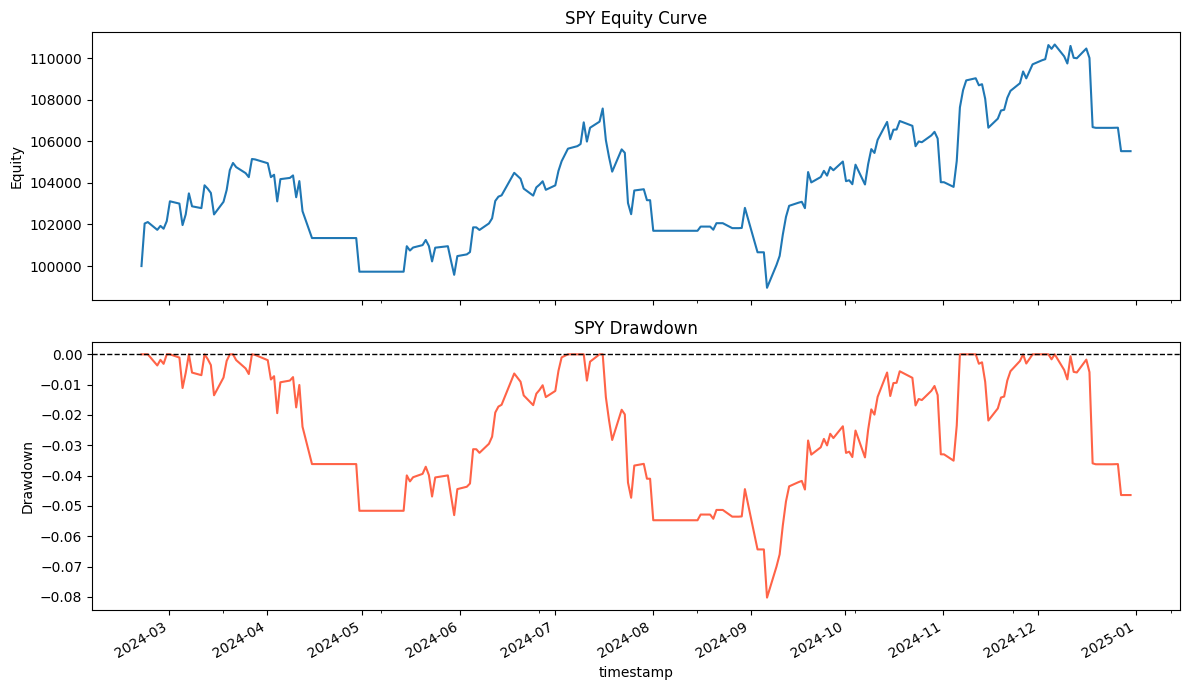

In [19]:
import matplotlib.pyplot as plt

if not steps_frame.empty:
    equity_plot = steps_frame.set_index('timestamp')['equity']
    drawdown_plot = equity_plot / equity_plot.cummax() - 1.0

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    equity_plot.plot(ax=axes[0], title=f'{symbol} Equity Curve')
    axes[0].set_ylabel('Equity')

    drawdown_plot.plot(ax=axes[1], title=f'{symbol} Drawdown', color='tomato')
    axes[1].set_ylabel('Drawdown')
    axes[1].axhline(0.0, color='black', linewidth=1, linestyle='--')

    plt.tight_layout()
    plt.show()
else:
    print('No backtest steps to plot.')


## Save Artifacts

This writes the same files the CLI backtest would produce.

In [20]:
artifact_dir = repo_root / 'artifacts' / 'notebook_runs' / f'{symbol}_{freq}_{start}_{end}'
saved_path = save_backtest_artifacts(result, artifact_dir)
saved_path

WindowsPath('C:/Users/Eddie/Programming/securities-analysis/artifacts/notebook_runs/SPY_day_2024-01-01_2024-12-31')

In [21]:
summary_path = Path(saved_path) / 'summary.json'
json.loads(summary_path.read_text(encoding='utf-8'))

{'symbol': 'SPY',
 'bars_processed': 251,
 'warmup_bars': 34,
 'trades': 183,
 'final_equity': 105530.32744985775,
 'cumulative_return': 0.055303274498577526,
 'risk_report': {'observations': 217,
  'annual_return': 0.06827915282078445,
  'annual_volatility': 0.10744148604567884,
  'sharpe_ratio': 0.6355008231341431,
  'sortino_ratio': 0.7167464703593345,
  'max_drawdown': -0.08022026183851294,
  'calmar_ratio': 0.8511459730489724,
  'value_at_risk_95': -0.012347847679540103,
  'expected_shortfall_95': -0.017684789470737258,
  'hit_rate': 0.4608294930875576,
  'profit_factor': 1.1308367905655672,
  'stability': 0.4174800650893312}}

## Notes For Debugging

If the notebook fails, common causes are:
- Alpaca keys no longer valid
- account endpoint changed or paper account disabled
- requested asset class/frequency unsupported for the symbol
- current Jupyter kernel is not using the environment that has `alpaca-py`

Once this notebook works for one symbol, we can add:
- multiple symbols
- benchmark comparison
- parameter sweeps
- walk-forward testing
- saved charts and richer diagnostics